# Sensitivity Analysis — Generation Stage (No Preprocessing Filter)

Replicates the full evaluation pipeline from `5_evaluation_main_v4.ipynb` on all 500 queries, without the completeness filter applied in the main analysis.

**Difference from main analysis:** The main notebook retains only queries where all 22 methods produced exactly 10 retrieved documents (500 → 402). This notebook includes all 500 queries. Query-method combinations where the generation was not run (target not retrieved) receive penalty rank 11 for both `target_citation_rank` and `target_retrieval_rank` — consistent with the penalty applied to non-cited documents in the main analysis.

**Input:**
- `data/retail/generation/4_generation_results_v4.parquet` — LLM generation results with citation orders per query-method combination

## Structure
1. **Setup** — imports and paths
2. **Load Data & Preprocessing** — derive outcome variables, expand to full 500 × 22 grid, impute missing runs with penalty rank 11
3. **Supporting Analysis** — tests whether retrieval rank predicts citation rank (Kendall's τ-c, baseline only, N = 500)
4. **Hypothesis 2** — tests whether GEO edits improve citation visibility (Wilcoxon signed-rank, 21 methods vs. baseline, N = 500 paired queries)

## 1. Setup

Imports all required libraries and defines file paths.

Paths are built relative to the current notebook directory (`os.getcwd()`). The project root sits two levels above the notebook, so all data paths resolve correctly regardless of where the project is stored on disk.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import wilcoxon, chi2          # wilcoxon: signed-rank test; chi2: Brant test
from statsmodels.stats.multitest import multipletests  # Bonferroni-Holm correction

# Project root is two levels up
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, "..", ".."))
data_dir     = os.path.join(project_root, "data", "retail")

print("Setup complete.")

Setup complete.


## 2. Load Data & Preprocessing

Loads the generation results from parquet and prepares the main DataFrame for all 500 queries — no completeness filter applied.

Instead of filtering, a full **500 × 22 grid** (500 queries × 22 methods) is constructed via a left join. Any query-method combination missing from the parquet (i.e. the target was not retrieved and generation was never run) is imputed with penalty rank 11 for both `target_citation_rank` and `target_retrieval_rank`, and 0 for `target_cited`.

- `target_retrieval_rank`: 1-based retrieval rank of the target document; **penalty rank 11 for runs where the target was not retrieved**
- `target_citation_rank`: 1-based citation position (1–10); not cited → penalty rank 11; **penalty rank 11 also for imputed runs that were never generated**
- `target_cited`: binary flag (1 = cited, 0 = not cited / not generated)

In [2]:
EXPECTED_METHODS = 22  # 21 GEO methods + baseline "doc"

# ── Load generation results ───────────────────────────────────────────────
results_path = os.path.join(data_dir, "generation/4_generation_results_v4.parquet")
df_raw = pd.read_parquet(results_path)

df_raw["citation_order"] = df_raw["citation_order"].apply(
    lambda x: x.tolist() if isinstance(x, np.ndarray) else x
)

# ── Derived columns (observed runs only) ───────────────────────────────────────────
# target_new_position is 0-based; add 1 for 1-based retrieval rank
df_raw["target_retrieval_rank"] = df_raw["target_new_position"] + 1

df_raw["target_cited"] = df_raw.apply(
    lambda row: 1 if row["target_new_position"] in row["citation_order"] else 0, axis=1
)

def get_citation_rank(row):
    """
    1-based citation position of the target document (1 = cited first).
    Non-cited documents receive penalty rank 11 (one beyond the max of 10).
    """
    order  = row["citation_order"]
    target = row["target_new_position"]
    if target in order:
        return order.index(target) + 1
    return 11

df_raw["target_citation_rank"] = df_raw.apply(get_citation_rank, axis=1)

# ── Expand to full 500 × 22 grid, impute missing runs with penalty 11 ─────────────────
# Missing runs = target not retrieved → cannot be generated or cited → penalty 11
all_query_ids     = df_raw["original_query_id"].unique()
all_method_labels = sorted(df_raw["method"].unique())

full_grid = pd.MultiIndex.from_product(
    [all_query_ids, all_method_labels], names=["original_query_id", "method"]
)
df = (
    pd.DataFrame(index=full_grid)
    .reset_index()
    .merge(df_raw, on=["original_query_id", "method"], how="left")
)

n_imputed = df["target_citation_rank"].isna().sum()

df["target_citation_rank"] = df["target_citation_rank"].fillna(11).astype(int)
df["target_retrieval_rank"] = df["target_retrieval_rank"].fillna(11).astype(int)
df["target_cited"]          = df["target_cited"].fillna(0).astype(int)

df_baseline = df[df["method"] == "doc"].reset_index(drop=True)
all_methods = sorted([m for m in df["method"].unique() if m != "doc"])

print(f"Total queries: {df['original_query_id'].nunique()} (no filter applied)")
print(f"Total rows: {len(df)} | Baseline: {len(df_baseline)} | Methods: {len(all_methods)}")
print(f"Imputed runs (penalty 11): {n_imputed}")

Total queries: 500 (no filter applied)
Total rows: 11000 | Baseline: 500 | Methods: 21
Imputed runs (penalty 11): 15


Quick check — verify column names, dtypes, and that derived columns look correct.

In [3]:
df.head()

,original_query_id,method,query_id,query,target_new_position,num_docs,citation_order,llm_response,target_retrieval_rank,target_cited,target_citation_rank
0,100162,Authoritative(doc),100162_Authoritative(doc),table lamps for bedroom,7.0,10.0,"[0, 1, 3, 4, 6, 9]","When selecting table lamps for your bedroom, s...",8,0,11
1,100162,CQ(doc),100162_CQ(doc),table lamps for bedroom,9.0,10.0,"[0, 1, 2, 4, 6, 5]",When searching for table lamps for your bedroo...,10,0,11
2,100162,CQS(doc),100162_CQS(doc),table lamps for bedroom,9.0,10.0,"[0, 1, 2, 4, 9]","When selecting table lamps for your bedroom, s...",10,1,5
3,100162,CS(doc),100162_CS(doc),table lamps for bedroom,9.0,10.0,"[0, 1, 3, 4, 7, 8]",When it comes to finding the right table lamps...,10,0,11
4,100162,Citations(doc),100162_Citations(doc),table lamps for bedroom,8.0,10.0,"[0, 1, 2, 3, 5, 6, 7]",When searching for table lamps for your bedroo...,9,0,11


Quick sanity check on the loaded data — expected dimensions and LLM response length to catch truncation or empty outputs.

In [4]:
print("=" * 50)
print("QUICK CHECK")
print("=" * 50)

# Dataset overview
print(f"Total runs:              {len(df)}")
print(f"Unique original queries: {df['original_query_id'].nunique()}")
print(f"Unique methods:          {df['method'].nunique()}")
print(f"Imputed runs (no llm_response): {df['llm_response'].isna().sum()}")

# LLM response length — only for observed (non-imputed) runs
observed = df["llm_response"].dropna()
df["response_length"] = df["llm_response"].apply(
    lambda x: len(x.split()) if isinstance(x, str) else np.nan
)
print(f"\nLLM Response Length (words, observed runs only):")
print(f"  Mean:   {df['response_length'].mean():.1f}")
print(f"  Median: {df['response_length'].median():.0f}")
print(f"  Min:    {df['response_length'].min()}")
print(f"  Max:    {df['response_length'].max()}")

QUICK CHECK
Total runs:              11000
Unique original queries: 500
Unique methods:          22
Imputed runs (no llm_response): 15

LLM Response Length (words, observed runs only):
  Mean:   374.0
  Median: 370
  Min:    119.0
  Max:    627.0


Citation range validation — verifies that all values in `citation_order` are within the valid 0-based index range (0–9). Any value outside this range would indicate a hallucinated document reference in the LLM response.

In [5]:
# Validate that citation_order contains only indices 0–9 (0-based)
# Any value >= 10 would correspond to [11] or higher in the LLM response — a hallucinated reference
# NaN rows = imputed runs (target not retrieved) — skipped here
all_indices = pd.Series([
    c for order in df['citation_order'] if isinstance(order, list) for c in order
])

print('Distribution of all citation_order values (0-based):')
print(all_indices.value_counts().sort_index().to_string())
print()
print(f'Min index: {all_indices.min()}  |  Max index: {all_indices.max()}')
out_of_range = all_indices[all_indices > 9]
print(f'Values > 9 (out-of-range): {len(out_of_range)}')
if len(out_of_range) > 0:
    print('WARNING:', out_of_range.value_counts().sort_index())
else:
    print('All citation indices are within 0–9. OK.')


Distribution of all citation_order values (0-based):
0    10633
1     9878
2     9005
3     7515
4     6159
5     4468
6     4017
7     3539
8     3073
9     2611

Min index: 0  |  Max index: 9
Values > 9 (out-of-range): 0
All citation indices are within 0–9. OK.


## 3. Supporting Analysis

Tests whether retrieval rank is monotonically associated with citation rank (baseline only, N = 500) using Kendall's τ-c.

The descriptive tables characterize the marginal distributions of both variables. The Brant test rules out ordinal logistic regression (proportional odds assumption violated), and MNLogit fails due to near-empty outcome categories — both analyses lead to Kendall's τ-c as the appropriate nonparametric test.

### Descriptive Analysis

Three tables characterizing the baseline sample (N = 500):
- **Table 1** — marginal distribution of `target_retrieval_rank` (1–10)
- **Table 2** — marginal distribution of `target_citation_rank` (1–10; penalty rank 11 = not cited or not generated)
- **Table 3** — median citation rank and % not cited broken down by retrieval rank; shows the core monotonic pattern

In [6]:
df_baseline_sa = df[df["method"] == "doc"].copy()  # sa = supporting analysis (baseline only)

# ── Table 1: Retrieval Rank Distribution ─────────────────────────────────────
rr        = df_baseline_sa["target_retrieval_rank"]
median_rr = rr.median()
q25_rr    = rr.quantile(0.25)
q75_rr    = rr.quantile(0.75)
iqr_rr    = q75_rr - q25_rr

print("=" * 60)
print(f"TABLE 1 — Retrieval Rank Distribution (Baseline-Only, N={len(df_baseline_sa)})")
print("Position of target document in Vertex AI Search results.")
print("=" * 60)
print(f"  Median: {median_rr:.1f}  |  Q25: {q25_rr:.1f}  |  Q75: {q75_rr:.1f}  |  IQR: {iqr_rr:.1f}")
print()
print(f"  {'Retrieval Rank':>15} {'N':>5} {'%':>8}")
print("  " + "-" * 30)
for rank, grp in df_baseline_sa.groupby("target_retrieval_rank"):
    n   = len(grp)
    pct = n / len(df_baseline_sa) * 100
    print(f"  {int(rank):>15} {n:>5} {pct:>7.1f}%")

# ── Table 2: Citation Rank Distribution ──────────────────────────────────────
cr          = df_baseline_sa["target_citation_rank"]
median_cr   = cr.median()
q25_cr      = cr.quantile(0.25)
q75_cr      = cr.quantile(0.75)
iqr_cr      = q75_cr - q25_cr
pct_penalty = (cr == 11).mean() * 100

print()
print("=" * 60)
print(f"TABLE 2 — Citation Rank Distribution (Baseline-Only, N={len(df_baseline_sa)})")
print("Non-cited documents receive fixed penalty rank 11.")
print("=" * 60)
print(f"  Median: {median_cr:.1f}  |  Q25: {q25_cr:.1f}  |  Q75: {q75_cr:.1f}  |  IQR: {iqr_cr:.1f}")
print(f"  Not Cited (Rank 11): {pct_penalty:.1f}%")
print()
print(f"  {'Citation Rank':>15} {'N':>5} {'%':>8}")
print("  " + "-" * 30)
for rank, grp in df_baseline_sa.groupby("target_citation_rank"):
    n   = len(grp)
    pct = n / len(df_baseline_sa) * 100
    print(f"  {int(rank):>15} {n:>5} {pct:>7.1f}%")

# ── Table 3: Median Citation Rank per Retrieval Rank ─────────────────────────
print()
print("=" * 65)
print(f"TABLE 3 — Median Citation Rank per Retrieval Rank (Baseline-Only, N={len(df_baseline_sa)})")
print("=" * 65)
print(f"  {'Retrieval Rank':>15} {'N':>5} {'Median Citation Rank':>22} {'% Not Cited':>13}")
print("-" * 65)
for rank, grp in df_baseline_sa.groupby("target_retrieval_rank"):
    n             = len(grp)
    median_cr_r   = grp["target_citation_rank"].median()
    pct_not_cited = (grp["target_citation_rank"] == 11).mean() * 100
    print(f"  {int(rank):>15} {n:>5} {median_cr_r:>22.1f} {pct_not_cited:>12.1f}%")

TABLE 1 — Retrieval Rank Distribution (Baseline-Only, N=500)
Position of target document in Vertex AI Search results.
  Median: 6.0  |  Q25: 3.0  |  Q75: 8.0  |  IQR: 5.0

   Retrieval Rank     N        %
  ------------------------------
                1    54    10.8%
                2    51    10.2%
                3    50    10.0%
                4    33     6.6%
                5    59    11.8%
                6    57    11.4%
                7    38     7.6%
                8    50    10.0%
                9    53    10.6%
               10    55    11.0%

TABLE 2 — Citation Rank Distribution (Baseline-Only, N=500)
Non-cited documents receive fixed penalty rank 11.
  Median: 5.0  |  Q25: 3.0  |  Q75: 11.0  |  IQR: 8.0
  Not Cited (Rank 11): 42.4%

    Citation Rank     N        %
  ------------------------------
                1    54    10.8%
                2    55    11.0%
                3    47     9.4%
                4    40     8.0%
                5    58    11.6%
     

### Scatterplot with LOWESS

Visualizes the relationship between retrieval rank (x) and citation rank (y) for baseline runs only.

Three visual layers:
- **Points (jittered):** Both variables are discrete integers (1–10 / 1–11), so without jitter all observations at the same coordinate would fully overlap. Uniform noise of ±0.2 is added to each axis for visibility.
- **LOWESS trend (red):** A non-parametric local smoother — does not assume linearity, which is appropriate given the Brant test result showing that the proportional odds assumption is violated.
- **Median per retrieval rank (orange dashed):** Concrete reference from Table 3, overlaid to anchor the smooth trend to the actual group medians.

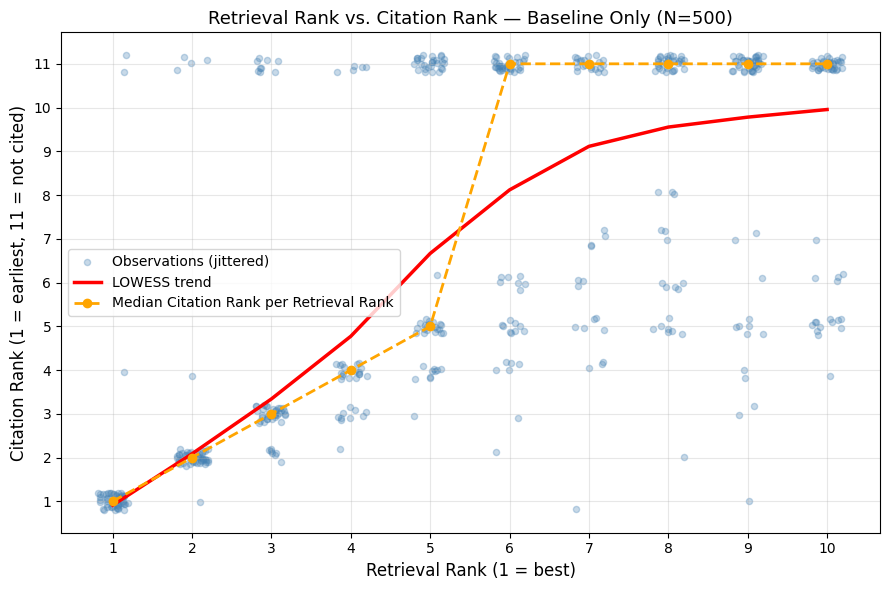

In [7]:
from statsmodels.nonparametric.smoothers_lowess import lowess

fig, ax = plt.subplots(figsize=(9, 6))

# Jitter both axes — without it, discrete integer values stack on identical coordinates
jitter_x = np.random.uniform(-0.2, 0.2, size=len(df_baseline_sa))
jitter_y = np.random.uniform(-0.2, 0.2, size=len(df_baseline_sa))

ax.scatter(
    df_baseline_sa["target_retrieval_rank"] + jitter_x,
    df_baseline_sa["target_citation_rank"] + jitter_y,
    alpha=0.3, s=20, color="steelblue", label="Observations (jittered)"
)

# LOWESS smooth — non-parametric, no linearity assumption; frac=0.5 controls bandwidth
smoothed = lowess(
    df_baseline_sa["target_citation_rank"],
    df_baseline_sa["target_retrieval_rank"],
    frac=0.5
)
ax.plot(smoothed[:, 0], smoothed[:, 1], color="red", linewidth=2.5, label="LOWESS trend")

# Median per retrieval rank — anchors the smooth trend to the actual group medians from Table 3
median_by_rank = df_baseline_sa.groupby("target_retrieval_rank")["target_citation_rank"].median()
ax.plot(median_by_rank.index, median_by_rank.values,
        color="orange", linewidth=2, linestyle="--",
        marker="o", markersize=6, label="Median Citation Rank per Retrieval Rank")

ax.set_xlabel("Retrieval Rank (1 = best)", fontsize=12)
ax.set_ylabel("Citation Rank (1 = earliest, 11 = not cited)", fontsize=12)
ax.set_title(f"Retrieval Rank vs. Citation Rank — Baseline Only (N={len(df_baseline_sa)})", fontsize=13)
ax.set_xticks(range(1, 11))
ax.set_yticks(range(1, 12))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Brant Test

Tests whether the proportional odds assumption of ordinal logistic regression holds — i.e., whether the effect of `target_retrieval_rank` on `target_citation_rank` is consistent across all cutpoints of the outcome scale.

The code proceeds in two steps:
1. **Pooled coefficient:** Fit a proportional odds model (ordinal logit) to obtain a single β₁ that assumes the effect is constant across cutpoints.
2. **Per-cutpoint coefficients:** For each cutpoint k (1–10), binarise the outcome as `y = (target_citation_rank ≤ k)` and fit a separate binary logistic regression. If proportional odds holds, these per-cutpoint β₁ values should be stable around the pooled estimate.

A chi-squared statistic tests whether the observed variation across cutpoints exceeds what is expected under H₀. A p-value shown as `< 1e-300` means the statistic exceeds floating-point precision — the violation is unambiguous, not a rounding artefact.

In [8]:
from statsmodels.miscmodels.ordinal_model import OrderedModel
import statsmodels.api as sm
from scipy.stats import chi2

# Fit proportional odds model internally to obtain pooled coefficient
ordered_result = OrderedModel(
    df_baseline_sa["target_citation_rank"].astype(int),
    df_baseline_sa[["target_retrieval_rank"]],
    distr="logit"
).fit(method="bfgs", disp=False)

beta_pooled = ordered_result.params["target_retrieval_rank"]
var_pooled  = ordered_result.cov_params().loc["target_retrieval_rank", "target_retrieval_rank"]

# Fit separate binary logit per cutpoint k: P(target_citation_rank <= k)
X = sm.add_constant(df_baseline_sa["target_retrieval_rank"].values)

coefs = []
for k in sorted(df_baseline_sa["target_citation_rank"].unique())[:-1]:
    y_binary = (df_baseline_sa["target_citation_rank"] <= k).astype(int)
    if y_binary.sum() < 5 or (1 - y_binary).sum() < 5:
        continue
    try:
        res = sm.Logit(y_binary, X).fit(disp=0)
        coefs.append({"cutpoint": int(k), "coef": res.params[1], "se": res.bse[1]})
    except:
        pass

df_coefs = pd.DataFrame(coefs)

# Chi-squared statistic: W = sum((β_j - β_pooled)² / SE_j²)
# Tests whether coefficients are homogeneous across cutpoints
W       = ((df_coefs["coef"] - beta_pooled) ** 2 / df_coefs["se"] ** 2).sum()
df_test = len(df_coefs) - 1
p_brant = chi2.sf(W, df=df_test)  # sf = 1 - cdf, numerically stable for large W

print("=" * 60)
print("Brant Test — Proportional Odds Assumption")
print("H0: β₁ is equal across all cutpoints")
print("=" * 60)
print(f"  Pooled β₁ (ordinal model): {beta_pooled:.4f}  (SE: {var_pooled**0.5:.4f})")
print()
print(f"  {'Cutpoint k':>10} {'β₁':>10} {'SE':>10}")
print("  " + "-" * 32)
for _, row in df_coefs.iterrows():
    print(f"  {row['cutpoint']:>10} {row['coef']:>10.4f} {row['se']:>10.4f}")
print()
print(f"  Mean β₁: {df_coefs['coef'].mean():.4f}")
print(f"  Std β₁:  {df_coefs['coef'].std():.4f}")
print(f"  Range:   {df_coefs['coef'].min():.4f} to {df_coefs['coef'].max():.4f}")
print()
print(f"  Chi-squared: {W:.3f}")
print(f"  df:          {df_test}")
p_str = "< 1e-300 (beyond float precision)" if p_brant == 0.0 else (f"{p_brant:.2e}" if p_brant < 0.001 else f"{p_brant:.4f}")
print(f"  p-value:     {p_str}  {'→ Proportional odds VIOLATED' if p_brant < 0.05 else '→ Proportional odds holds'}")


Brant Test — Proportional Odds Assumption
H0: β₁ is equal across all cutpoints
  Pooled β₁ (ordinal model): 0.7814  (SE: 0.0494)

  Cutpoint k         β₁         SE
  --------------------------------
         1.0    -2.3201     0.3417
         2.0    -1.5521     0.1723
         3.0    -1.1997     0.1106
         4.0    -0.9176     0.0782
         5.0    -0.5308     0.0465
         6.0    -0.4594     0.0428
         7.0    -0.4232     0.0412
         8.0    -0.4132     0.0408

  Mean β₁: -0.9770
  Std β₁:  0.6844
  Range:   -2.3201 to -0.4132

  Chi-squared: 4406.776
  df:          7
  p-value:     < 1e-300 (beyond float precision)  → Proportional odds VIOLATED


/var/folders/lf/6rsckgz10_93vpjm3kxh6b5h0000gn/T/ipykernel_55690/852326448.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coefs.append({"cutpoint": int(k), "coef": res.params[1], "se": res.bse[1]})
/var/folders/lf/6rsckgz10_93vpjm3kxh6b5h0000gn/T/ipykernel_55690/852326448.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coefs.append({"cutpoint": int(k), "coef": res.params[1], "se": res.bse[1]})
/var/folders/lf/6rsckgz10_93vpjm3kxh6b5h0000gn/T/ipykernel_55690/852326448.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated a

Consistent with the main analysis: **the proportional odds assumption is clearly violated** (p < 1e-300). Kendall's τ-c is used as the inferential test instead of ordinal logistic regression.

### Multinomial Logistic Regression

Tested as an alternative to ordinal logistic regression after the Brant test showed that proportional odds is violated. Unlike OLR, MNLogit estimates a separate coefficient for each outcome category (except the reference), making no assumption about the ordering of categories.

The code fits MNLogit with `target_retrieval_rank` as the single predictor and `target_citation_rank` (11 categories) as the outcome, then prints the full coefficient table and standard errors per category.

In [9]:
from statsmodels.discrete.discrete_model import MNLogit

# MNLogit estimates a separate coefficient per outcome category — no proportional odds assumption
X = sm.add_constant(df_baseline_sa["target_retrieval_rank"].values)
y = df_baseline_sa["target_citation_rank"].values

try:
    model  = MNLogit(y, X)
    result = model.fit(disp=0)
    print(result.summary())
    print()
    print("Standard Errors per Category:")
    print(result.bse)
except Exception as e:
    # Near-empty categories (ranks 7–8) and absent ranks (9–10) cause softmax overflow during MLE
    print(f"Model failed: {e}")


/opt/anaconda3/envs/seo_geo_env/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:3027: RuntimeWarning: overflow encountered in exp
  eXB = np.column_stack((np.ones(len(X)), np.exp(X)))
/opt/anaconda3/envs/seo_geo_env/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:3028: RuntimeWarning: invalid value encountered in divide
  return eXB/eXB.sum(1)[:,None]


                          MNLogit Regression Results                          
Dep. Variable:                      y   No. Observations:                  500
Model:                        MNLogit   Df Residuals:                      484
Method:                           MLE   Df Model:                            8
Date:                Sat, 16 May 2026   Pseudo R-squ.:                     nan
Time:                        12:34:18   Log-Likelihood:                    nan
converged:                       True   LL-Null:                       -881.62
Covariance Type:            nonrobust   LLR p-value:                       nan
       y=2       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const             nan        nan        nan        nan         nan         nan
x1                nan        nan        nan        nan         nan         nan
----------------------------------------------------

Consistent with the main analysis: MNLogit fails to produce stable estimates due to near-empty citation rank categories (ranks 9 and 10 absent, rank 8 with only 3 observations). **MNLogit is not viable here.** Kendall's τ-c is used as the inferential test instead.

### Tie Analysis

τ-c is chosen over τ-b because it handles asymmetric table dimensions — retrieval rank (1–10) and citation rank (1–11) have different scales. For τ-c to be the appropriate choice, ties must also be substantial in both variables. The code below verifies this.

The code counts the number of tied pairs (pairs of observations sharing the same rank value) for `target_retrieval_rank` and `target_citation_rank`, and expresses each as a share of all possible pairs N(N−1)/2.

In [10]:
# Count tied pairs for each variable: n_k*(n_k-1)/2 per value group, summed
rr_counts = df_baseline_sa["target_retrieval_rank"].value_counts().sort_index()
rr_ties   = (rr_counts * (rr_counts - 1) / 2).sum()

cr_counts = df_baseline_sa["target_citation_rank"].value_counts().sort_index()
cr_ties   = (cr_counts * (cr_counts - 1) / 2).sum()

n           = len(df_baseline_sa)
total_pairs = n * (n - 1) / 2  # total number of observation pairs

print("=" * 55)
print(f"Tie Analysis — Baseline-Only (N={n})")
print("=" * 55)
print(f"\nRetrieval Rank:")
print(f"  Tie pairs:     {int(rr_ties):>6}")
print(f"  % of all pairs: {rr_ties/total_pairs*100:>5.1f}%")
print(f"\nCitation Rank:")
print(f"  Tie pairs:     {int(cr_ties):>6}")
print(f"  % of all pairs: {cr_ties/total_pairs*100:>5.1f}%")
print(f"\nTotal possible pairs: {int(total_pairs)}")


Tie Analysis — Baseline-Only (N=500)

Retrieval Rank:
  Tie pairs:      12557
  % of all pairs:  10.1%

Citation Rank:
  Tie pairs:      29054
  % of all pairs:  23.3%

Total possible pairs: 124750


Consistent with the main analysis: ties are substantial in both variables (RR: 10.1%, CR: 23.3%), confirming τ-c as the appropriate variant. The citation rank tie rate is slightly higher than in the filtered analysis (23.3% vs. 23.7%).

### Kendall's τ-c

The code computes Kendall's τ-c using `scipy.stats.kendalltau` with `variant="c"`, derives the Gilpin (1993) effect size r = sin(0.5π τ-c), and constructs a 95% bootstrap confidence interval by resampling the 402 observation pairs 10,000 times.

In [11]:
from scipy.stats import kendalltau

np.random.seed(42)

rr = df_baseline_sa["target_retrieval_rank"].values
cr = df_baseline_sa["target_citation_rank"].values
N  = len(rr)

# variant="c" handles asymmetric scales (RR: 1–10, CR: 1–11) and substantial ties
tau, pvalue = kendalltau(rr, cr, variant="c")

# Gilpin (1993) effect size: r = sin(0.5π τ-c)
r_gilpin = np.sin(0.5 * np.pi * tau)

# Bootstrap 95% CI: resample pairs with replacement, recompute τ-c each time
boot_taus = []
for _ in range(10000):
    idx = np.random.choice(N, size=N, replace=True)
    t, _ = kendalltau(rr[idx], cr[idx], variant="c")
    boot_taus.append(t)
ci_lower, ci_upper = np.percentile(boot_taus, [2.5, 97.5])

def cohen_r(r):
    a = abs(r)
    if a < 0.1:  return "negligible"
    if a < 0.3:  return "small"
    if a < 0.5:  return "medium"
    return "large"

p_str = "< 1e-300 (beyond float precision)" if pvalue == 0.0 else (f"{pvalue:.2e}" if pvalue < 0.001 else f"{pvalue:.4f}")

print("=" * 60)
print("Kendall's τ-c: Retrieval Rank → Citation Rank")
print(f"Baseline-only (N={N})")
print("=" * 60)
print(f"  τ-c:          {tau:>8.4f}  95% CI [{ci_lower:+.4f}, {ci_upper:+.4f}]")
print(f"  p-value:      {p_str}  {'*' if pvalue < 0.05 else 'ns'}")
print(f"  r (Gilpin):   {r_gilpin:>8.4f}  [{cohen_r(r_gilpin)}, Cohen 1992]")
print()
if pvalue < 0.05 and tau > 0:
    print("→ Significant positive association.")
    print("  A worse retrieval rank is associated with a later citation rank.")
elif pvalue < 0.05 and tau < 0:
    print("→ Significant negative association — unexpected direction.")
else:
    print("→ No significant association detected.")
print()
print("τ-c: -1 to +1. Positive = worse retrieval → later citation.")
print("95% CI via bootstrap (10,000 iterations, seed 42).")
print("r = sin(0.5 π τ-c) — Gilpin (1993). Cohen (1992): <.1 negligible, .1–.3 small, .3–.5 medium, >.5 large.")


Kendall's τ-c: Retrieval Rank → Citation Rank
Baseline-only (N=500)
  τ-c:            0.5769  95% CI [+0.5164, +0.6343]
  p-value:      1.26e-72  *
  r (Gilpin):     0.7871  [large, Cohen 1992]

→ Significant positive association.
  A worse retrieval rank is associated with a later citation rank.

τ-c: -1 to +1. Positive = worse retrieval → later citation.
95% CI via bootstrap (10,000 iterations, seed 42).
r = sin(0.5 π τ-c) — Gilpin (1993). Cohen (1992): <.1 negligible, .1–.3 small, .3–.5 medium, >.5 large.


Consistent with the main analysis: τ-c = 0.577 (95% CI [+0.516, +0.634]), p = 1.26e-72, r = 0.787 — positive, significant, and large. The association is slightly stronger than in the filtered sample (τ-c = 0.552, r = 0.763), consistent with the larger sample including more imputed penalty-11 cases at high retrieval ranks.

## 4. Hypothesis 2

**H2:** Content-based GEO edits significantly enhance a document's citation visibility within the LLM-generated response.

For each of the 21 GEO methods, citation rank is compared against the baseline in a paired design (N = 500). The analysis includes descriptive statistics, a symmetry check, and the Wilcoxon signed-rank test with Pratt modification as the primary inferential test, followed by the Sign Test as a robustness check. Bonferroni-Holm correction is applied across all 21 comparisons.

### Descriptive Analysis

For each of the 21 GEO methods, the code merges baseline and method citation ranks on `original_query_id` to form a paired dataset, then computes the shift (baseline − method) per query. A positive shift means the GEO edit cited the target earlier; a negative shift means it cited it later; zero means no change.

**Table 1 — Distribution Summary:** Median and mean `target_citation_rank` for baseline and method, plus the shift distribution. Zeros and % Zeros quantify how often the GEO edit produced no change — directly relevant to the Wilcoxon Pratt modification, which retains zero differences in the ranking step before exclusion.

**Table 2 — Ranking Performance:** Share of queries where the target appeared in citation positions 1–3 (top-3 rate), and the directional breakdown of shifts (% Improved / Unchanged / Worsened).

In [12]:
# Paired DataFrame: baseline vs. each method, merged on original_query_id
base_cr = (
    df[df["method"] == "doc"][["original_query_id", "target_citation_rank"]]
    .rename(columns={"target_citation_rank": "cr_baseline"})
)

rows = []
for method in all_methods:
    method_cr = (
        df[df["method"] == method][["original_query_id", "target_citation_rank"]]
        .rename(columns={"target_citation_rank": "cr_method"})
    )
    merged           = base_cr.merge(method_cr, on="original_query_id")
    # Positive shift = method cited target earlier; negative = later; zero = no change
    merged["shift"]  = merged["cr_baseline"] - merged["cr_method"]
    merged["method"] = method
    rows.append(merged)

paired_cr = pd.concat(rows, ignore_index=True)

# Helper aggregations
def q25(x):      return x.quantile(0.25)
def q75(x):      return x.quantile(0.75)
def top3_pct(x): return (x <= 3).mean() * 100
def zeros(x):    return (x == 0).sum()
def pct_zeros(x): return (x == 0).mean() * 100

# Directional label per pair — used in Table 2 breakdown
paired_cr["status"] = np.select(
    [paired_cr["shift"] > 0, paired_cr["shift"] < 0],
    ["Improved", "Worsened"],
    default="Unchanged"
)

dist = paired_cr.groupby("method").agg(
    N             = ("original_query_id", "count"),
    Median_Base   = ("cr_baseline",       "median"),
    Median_Method = ("cr_method",         "median"),
    Median_Shift  = ("shift",             "median"),
    Mean_Base     = ("cr_baseline",       "mean"),
    Mean_Method   = ("cr_method",         "mean"),
    Mean_Shift    = ("shift",             "mean"),
    Zeros         = ("shift",             zeros),
    Pct_Zeros     = ("shift",             pct_zeros),
)

perf = paired_cr.groupby("method").agg(
    Top3_Base_Pct = ("cr_baseline", top3_pct),
    Top3_Meth_Pct = ("cr_method",   top3_pct),
)
perf["Top3_Delta"] = perf["Top3_Meth_Pct"] - perf["Top3_Base_Pct"]

status_counts = (
    paired_cr.groupby(["method", "status"])
    .size().unstack(fill_value=0)
    .reindex(columns=["Improved", "Unchanged", "Worsened"], fill_value=0)
)
status_pct = status_counts.div(status_counts.sum(axis=1), axis=0) * 100
status_pct.columns = ["% Improved", "% Unchanged", "% Worsened"]

master = dist.join(perf).join(status_pct)
master = master.sort_values("Mean_Shift", ascending=False)

# Baseline reference row — shown separately since shift is undefined for baseline vs. itself
base_vals = df[df["method"] == "doc"]["target_citation_rank"]
base_n    = len(base_vals)
base_med  = base_vals.median()
base_mean = base_vals.mean()
base_top3 = top3_pct(base_vals)

# Table 1 — Distribution Summary
print("=" * 100)
print("TABLE 1 — Distribution Summary  |  Delta Citation Rank = Baseline − Method")
print("Positive shift = improvement. Non-cited documents receive penalty rank 11.")
print("=" * 100)
print(f"  {'Method':<26} {'N':>4}  {'Med.Base':>8} {'Med.Meth':>9} {'Med.Shift':>10}  {'Mean.Base':>9} {'Mean.Meth':>10} {'Mean.Shift':>11}  {'Zeros':>6} {'%Zeros':>7}")
print("-" * 100)
print(f"  {'Baseline (doc)':<26} {base_n:>4}  {base_med:>8.1f} {'—':>9} {'—':>10}  {base_mean:>9.3f} {'—':>10} {'—':>11}  {'—':>6} {'—':>7}")
print()
for method, row in master.iterrows():
    print(f"  {method:<26} {row['N']:>4}  "
          f"{row['Median_Base']:>8.1f} {row['Median_Method']:>9.1f} {row['Median_Shift']:>+10.1f}  "
          f"{row['Mean_Base']:>9.3f} {row['Mean_Method']:>10.3f} {row['Mean_Shift']:>+11.3f}  "
          f"{row['Zeros']:>6.0f} {row['Pct_Zeros']:>6.1f}%")

# Table 2 — Ranking Performance Summary
print()
print("=" * 80)
print("TABLE 2 — Ranking Performance Summary")
print("Top-3% = proportion of queries where target appeared in citation positions 1–3.")
print("=" * 80)
print(f"  {'Method':<26}  {'%Top3.B':>8} {'%Top3.M':>8} {'ΔTop3%':>8}  {'%Impr':>7} {'%Unch':>7} {'%Wors':>7}")
print("-" * 80)
print(f"  {'Baseline (doc)':<26}  {base_top3:>7.1f}% {'—':>8} {'—':>8}  {'—':>7} {'—':>7} {'—':>7}")
print()
for method, row in master.iterrows():
    print(f"  {method:<26}  "
          f"{row['Top3_Base_Pct']:>7.1f}% {row['Top3_Meth_Pct']:>7.1f}% {row['Top3_Delta']:>+7.1f}%  "
          f"{row['% Improved']:>6.1f}% {row['% Unchanged']:>6.1f}% {row['% Worsened']:>6.1f}%")
print()
print("Sorted by Mean Shift descending.")


TABLE 1 — Distribution Summary  |  Delta Citation Rank = Baseline − Method
Positive shift = improvement. Non-cited documents receive penalty rank 11.
  Method                        N  Med.Base  Med.Meth  Med.Shift  Mean.Base  Mean.Meth  Mean.Shift   Zeros  %Zeros
----------------------------------------------------------------------------------------------------
  Baseline (doc)              500       5.0         —          —      6.614          —           —       —       —

  SimpleLanguage(doc)        500.0       5.0       5.0       +0.0      6.614      6.506      +0.108     270   54.0%
  Citations(doc)             500.0       5.0       6.0       +0.0      6.614      6.784      -0.170     260   52.0%
  Authoritative(doc)         500.0       5.0       6.0       +0.0      6.614      6.792      -0.178     252   50.4%
  TechnicalTerms(doc)        500.0       5.0       6.0       +0.0      6.614      6.806      -0.192     259   51.8%
  Quotes(doc)                500.0       5.0       6.0

### Symmetry Check

The Wilcoxon signed-rank test assumes that the distribution of pairwise differences is symmetric around the median. The histograms below visualize the full Δ Citation Rank distribution for each method, and the symmetry table tests this assumption formally by computing skewness and a standardised z-score — a method is flagged as asymmetric if |z| > 1.96.

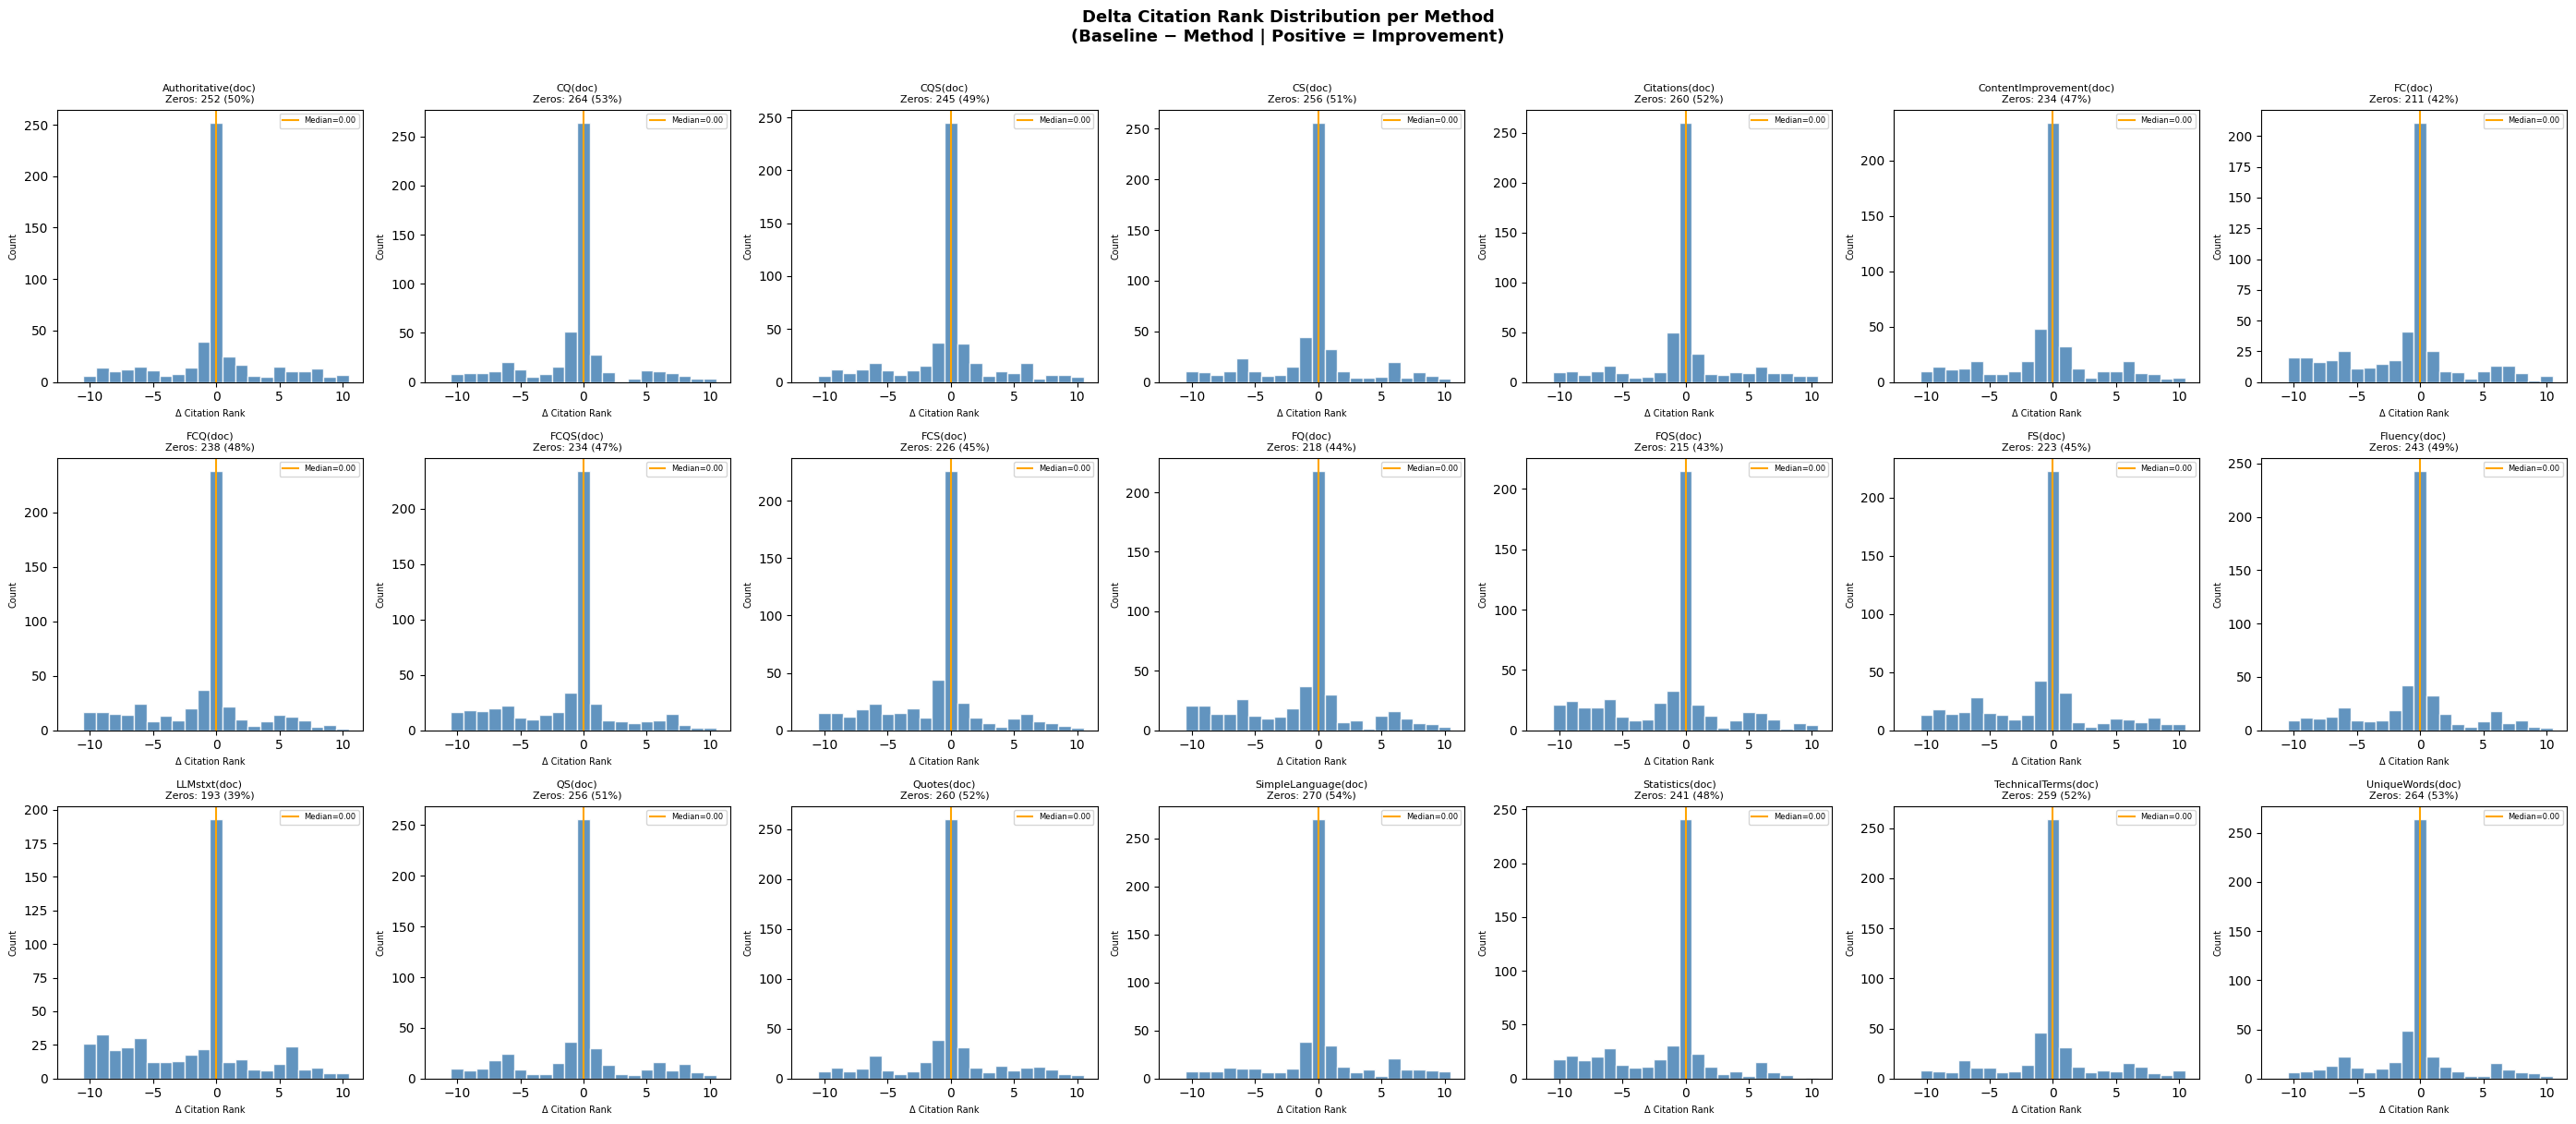

,Method,N,Zeros,% Zeros,Median,Skewness,Standardised z,Asymmetric |z|>1.96
0,Authoritative(doc),500,252,50.4,0.0,-0.050,-0.460,False
1,FQS(doc),500,215,43.0,0.0,-0.181,-1.650,False
2,TechnicalTerms(doc),500,259,51.8,0.0,-0.057,-0.517,False
3,Statistics(doc),500,241,48.2,0.0,-0.449,-4.099,True
4,SimpleLanguage(doc),500,270,54.0,0.0,0.027,0.248,False
5,Quotes(doc),500,260,52.0,0.0,-0.190,-1.734,False
6,QS(doc),500,256,51.2,0.0,-0.114,-1.037,False
7,LLMstxt(doc),500,193,38.6,0.0,-0.031,-0.283,False
8,Fluency(doc),500,243,48.6,0.0,-0.260,-2.373,True
9,FS(doc),500,223,44.6,0.0,-0.062,-0.563,False


In [13]:
from scipy.stats import skew

# 3×7 grid — one histogram per GEO method showing the full Δ Citation Rank distribution
fig, axes = plt.subplots(3, 7, figsize=(28, 12))
axes = axes.flatten()

for idx, method in enumerate(all_methods):
    merged = base_cr.merge(
        df[df["method"] == method][["original_query_id", "target_citation_rank"]]
        .rename(columns={"target_citation_rank": "cr_method"}),
        on="original_query_id"
    )
    diffs     = (merged["cr_baseline"] - merged["cr_method"]).values
    n_zeros   = (diffs == 0).sum()
    pct_zeros = n_zeros / len(diffs) * 100

    ax = axes[idx]
    ax.hist(diffs, bins=range(-11, 12), align="left", color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(0, color="red", linewidth=1.2, linestyle="--")
    ax.axvline(np.median(diffs), color="orange", linewidth=1.5, label=f"Median={np.median(diffs):.2f}")
    ax.set_title(f"{method}\nZeros: {n_zeros} ({pct_zeros:.0f}%)", fontsize=8)
    ax.set_xlabel("Δ Citation Rank", fontsize=7)
    ax.set_ylabel("Count", fontsize=7)
    ax.legend(fontsize=6)

for j in range(len(all_methods), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Delta Citation Rank Distribution per Method\n(Baseline − Method | Positive = Improvement)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Symmetry summary table — skewness z-score; |z| > 1.96 flags violation of Wilcoxon symmetry assumption
symmetry_rows = []
for method in all_methods:
    merged = base_cr.merge(
        df[df["method"] == method][["original_query_id", "target_citation_rank"]]
        .rename(columns={"target_citation_rank": "cr_method"}),
        on="original_query_id"
    )
    diffs = (merged["cr_baseline"] - merged["cr_method"]).values
    n     = len(diffs)
    sk    = skew(diffs)
    se    = np.sqrt(6 / n)  # standard error of skewness under normality
    z     = sk / se
    symmetry_rows.append({
        "Method":              method,
        "N":                   n,
        "Zeros":               int((diffs == 0).sum()),
        "% Zeros":             round((diffs == 0).mean() * 100, 1),
        "Median":              round(float(np.median(diffs)), 3),
        "Skewness":            round(sk, 3),
        "Standardised z":      round(z, 3),
        "Asymmetric |z|>1.96": abs(z) > 1.96,
    })

symmetry_df = pd.DataFrame(symmetry_rows).sort_values("Median", ascending=False).reset_index(drop=True)
display(symmetry_df)


5 of 21 methods show statistically significant skewness (|z| > 1.96): ContentImprovement, FCQ, FCQS, Fluency, and Statistics — all negatively skewed. This is one fewer than in the main analysis (6/21), where CS additionally violated the assumption. The Sign Test is applied uniformly as a robustness check across all 21 methods.

### Wilcoxon Signed-Rank Test

Tests whether each GEO method shifts citation rank relative to the baseline. For each method, paired differences (Δ = baseline − method) are computed per query and a Wilcoxon signed-rank test with Pratt modification is applied. The Pratt modification retains zero differences in the ranking step before exclusion.

`calculate_significant_improvements` returns p-values for three alternatives (greater, less, two-sided) and an effect size r = |Z| / √N derived directly from the W statistic to avoid floating-point saturation.

In [14]:
def calculate_significant_improvements(df_baseline, df_method):
    """
    Computes Delta Rank for each paired query:
        delta = baseline_target_citation_rank - method_target_citation_rank

    Positive = method cited target earlier (improvement).
    Negative = method cited target later (deterioration).

    Uses target_citation_rank directly (1-based, 1–10; non-cited = penalty 11).
    Both DataFrames must be pre-sorted and aligned on original_query_id.
    Applies Wilcoxon signed-rank test with Pratt modification (zeros retained).
    Adapted from Puerto (2025).
    """
    from scipy.stats import rankdata

    diffs = (
        df_baseline["target_citation_rank"].values
        - df_method["target_citation_rank"].values
    ).tolist()

    if len(diffs) == 0:
        return {"statistic": None, "pvalue_greater": None, "pvalue_less": None,
                "pvalue_twosided": None, "Delta Rank": (None, None), "diffs": [], "r_effect": None}

    # Pratt modification: zeros are ranked before exclusion, reducing bias in zero-inflated distributions
    stat_g, pval_g = wilcoxon(diffs, alternative="greater",   zero_method="pratt")
    stat_l, pval_l = wilcoxon(diffs, alternative="less",      zero_method="pratt")
    stat_t, pval_t = wilcoxon(diffs, alternative="two-sided", zero_method="pratt")

    median_diff = np.median(diffs)
    mean_diff   = np.mean(diffs)
    N           = len(diffs)

    # Effect size r = |Z| / sqrt(N): Z derived directly from W to avoid float saturation at extreme p-values
    diffs_arr = np.array(diffs)
    n_z       = int((diffs_arr == 0).sum())      # number of zero differences (Pratt: ranked but excluded)
    ranks     = rankdata(np.abs(diffs_arr))
    w_plus    = ranks[diffs_arr > 0].sum()        # sum of ranks for positive differences
    mu        = (N * (N + 1) - n_z * (n_z + 1)) / 4
    sigma     = np.sqrt((N * (N + 1) * (2 * N + 1) - n_z * (n_z + 1) * (2 * n_z + 1)) / 24)
    z_stat    = (w_plus - mu) / sigma
    r_effect  = abs(z_stat) / np.sqrt(N)

    return {
        "statistic":       stat_g,
        "pvalue_greater":  pval_g,
        "pvalue_less":     pval_l,
        "pvalue_twosided": pval_t,
        "Delta Rank":      (median_diff, mean_diff),
        "diffs":           diffs,
        "r_effect":        r_effect,
    }


### Wilcoxon Test — Confirmatory (Greater)

Tests whether each GEO method improves citation rank relative to the baseline (H₁: shift > 0). For each method, `calculate_significant_improvements` computes the Wilcoxon signed-rank statistic with Pratt modification and returns p-values for all three alternatives. Effect size r = |Z| / √N is derived directly from the W statistic, and bootstrapped 95% CIs (10,000 iterations) are computed separately. Bonferroni-Holm correction is applied across all 21 comparisons.

In [15]:
np.random.seed(42)

def bootstrap_effect_size_delta(diffs, n_iterations=10000):
    """
    Bootstrapped 95% CI for Wilcoxon effect size r = |Z| / sqrt(N).
    Uses Pratt modification: zero-differences are ranked before exclusion.
    Z computed directly from W statistic.
    """
    from scipy.stats import rankdata
    diffs = np.array(diffs)
    n     = len(diffs)
    boot_effects = []

    for _ in range(n_iterations):
        idx        = np.random.choice(n, size=n, replace=True)
        boot_diffs = diffs[idx]
        n_z        = int((boot_diffs == 0).sum())
        if n_z == n:  # all zeros — effect size undefined, skip iteration
            continue
        ranks  = rankdata(np.abs(boot_diffs))
        w_plus = ranks[boot_diffs > 0].sum()
        mu     = (n * (n + 1) - n_z * (n_z + 1)) / 4
        sigma  = np.sqrt((n * (n + 1) * (2 * n + 1) - n_z * (n_z + 1) * (2 * n_z + 1)) / 24)
        z_stat = (w_plus - mu) / sigma
        boot_effects.append(abs(z_stat) / np.sqrt(n))

    return np.percentile(boot_effects, 2.5), np.percentile(boot_effects, 97.5)


def fmt_p(p):
    if p is None:
        return "—"
    if p == 0.0:
        return "< 1e-300"
    return f"{p:.2e}" if p < 0.001 else f"{p:.4f}"


def sig_stars(p):
    if p is None:
        return "—"
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"


# Run Wilcoxon + bootstrap CI for all 21 methods
results_delta = []
for method in all_methods:
    df_m   = df[df["method"] == method].sort_values("original_query_id").reset_index(drop=True)
    df_b_a = df_baseline.sort_values("original_query_id").reset_index(drop=True)
    res    = calculate_significant_improvements(df_b_a, df_m)

    ci_lower, ci_upper = bootstrap_effect_size_delta(res["diffs"])

    results_delta.append({
        "method":                 method,
        "n_queries":              len(df_m),
        "delta_citation_rank":      res["Delta Rank"][0],
        "delta_citation_rank_mean": res["Delta Rank"][1],
        "pvalue_greater":         res["pvalue_greater"],
        "pvalue_less":            res["pvalue_less"],
        "pvalue_twosided":        res["pvalue_twosided"],
        "r_effect":               res["r_effect"],
        "ci_lower":               ci_lower,
        "ci_upper":               ci_upper,
        "diffs":                  res["diffs"],
    })

# Sort by mean shift descending; apply Holm correction for the greater (confirmatory) direction
df_results = pd.DataFrame(results_delta).sort_values("delta_citation_rank_mean", ascending=False)

_, pg_holm, _, _ = multipletests(df_results["pvalue_greater"].values, method="holm")
df_results["pvalue_greater_holm"] = pg_holm

print("Confirmatory — Wilcoxon One-Sided (greater) + Pratt")
print("Bonferroni-Holm correction applied across 21 comparisons")
print()
print(f"{'Method':<30} {'Med.Shift':>10} {'Mean.Shift':>11} {'p':>11} {'Sig':>5} {'p (Holm)':>12} {'Sig':>5} {'r':>7} {'95% CI':>18}")
print("-" * 119)
for _, row in df_results.iterrows():
    ci_str = f"[{row['ci_lower']:+.3f}, {row['ci_upper']:+.3f}]"
    print(
        f"  {row['method']:<28} {row['delta_citation_rank']:>10.3f} {row['delta_citation_rank_mean']:>+11.3f}"
        f" {fmt_p(row['pvalue_greater']):>11} {sig_stars(row['pvalue_greater']):>5}"
        f" {fmt_p(row['pvalue_greater_holm']):>12} {sig_stars(row['pvalue_greater_holm']):>5}"
        f" {row['r_effect']:>7.4f} {ci_str:>18}"
    )
print()
print("Med.Shift = median(baseline \u2212 method) delta_citation_rank. Positive = cited earlier.")
print("Effect size r = |Z| / \u221aN: 0.1 = small, 0.3 = medium, 0.5 = large.")


Confirmatory — Wilcoxon One-Sided (greater) + Pratt
Bonferroni-Holm correction applied across 21 comparisons

Method                          Med.Shift  Mean.Shift           p   Sig     p (Holm)   Sig       r             95% CI
-----------------------------------------------------------------------------------------------------------------------
  SimpleLanguage(doc)               0.000      +0.108      0.3075    ns       1.0000    ns  0.0225   [+0.002, +0.111]
  Citations(doc)                    0.000      -0.170      0.9344    ns       1.0000    ns  0.0674   [+0.005, +0.157]
  Authoritative(doc)                0.000      -0.178      0.9043    ns       1.0000    ns  0.0584   [+0.004, +0.143]
  TechnicalTerms(doc)               0.000      -0.192      0.9483    ns       1.0000    ns  0.0728   [+0.005, +0.160]
  Quotes(doc)                       0.000      -0.260      0.9458    ns       1.0000    ns  0.0718   [+0.005, +0.157]
  CQS(doc)                          0.000      -0.278      0.9

Consistent with the main analysis: no GEO method significantly improves citation rank. The best-performing method is SimpleLanguage (p = 0.308, p_holm = 1.0) — further from significance than in the main analysis (p = 0.152). **H2 is not supported in the positive direction.**

### Wilcoxon Test — Exploratory (Less)

Post-hoc exploratory test — one-sided Wilcoxon (alternative = less) with Bonferroni-Holm correction. Tests whether each GEO method worsens citation rank relative to the baseline (H₁: shift < 0). Uses the same effect sizes and bootstrapped CIs computed above.

In [16]:
# Apply Holm correction for the less (exploratory) direction — reuses df_results from above
_, pl_holm, _, _ = multipletests(df_results["pvalue_less"].values, method="holm")
df_results["pvalue_less_holm"] = pl_holm

print("Post Hoc Exploratory — Wilcoxon One-Sided (less) + Pratt")
print("Bonferroni-Holm correction applied across 21 comparisons")
print()
print(f"{'Method':<30} {'Med.Shift':>10} {'Mean.Shift':>11} {'p':>11} {'Sig':>5} {'p (Holm)':>12} {'Sig':>5} {'r':>7} {'95% CI':>18}")
print("-" * 119)
for _, row in df_results.iterrows():
    ci_str = f"[{row['ci_lower']:+.3f}, {row['ci_upper']:+.3f}]"
    print(
        f"  {row['method']:<28} {row['delta_citation_rank']:>10.3f} {row['delta_citation_rank_mean']:>+11.3f}"
        f" {fmt_p(row['pvalue_less']):>11} {sig_stars(row['pvalue_less']):>5}"
        f" {fmt_p(row['pvalue_less_holm']):>12} {sig_stars(row['pvalue_less_holm']):>5}"
        f" {row['r_effect']:>7.4f} {ci_str:>18}"
    )
print()
print("Med.Shift = median(baseline \u2212 method) delta_citation_rank. Negative = method worsened position.")
print("Effect size r = |Z| / \u221aN: 0.1 = small, 0.3 = medium, 0.5 = large.")


Post Hoc Exploratory — Wilcoxon One-Sided (less) + Pratt
Bonferroni-Holm correction applied across 21 comparisons

Method                          Med.Shift  Mean.Shift           p   Sig     p (Holm)   Sig       r             95% CI
-----------------------------------------------------------------------------------------------------------------------
  SimpleLanguage(doc)               0.000      +0.108      0.6925    ns       0.6925    ns  0.0225   [+0.002, +0.111]
  Citations(doc)                    0.000      -0.170      0.0656    ns       0.3100    ns  0.0674   [+0.005, +0.157]
  Authoritative(doc)                0.000      -0.178      0.0957    ns       0.3100    ns  0.0584   [+0.004, +0.143]
  TechnicalTerms(doc)               0.000      -0.192      0.0517    ns       0.3100    ns  0.0728   [+0.005, +0.160]
  Quotes(doc)                       0.000      -0.260      0.0542    ns       0.3100    ns  0.0718   [+0.005, +0.157]
  CQS(doc)                          0.000      -0.278    

14 of 21 methods significantly worsen citation rank after Holm correction — two more than in the main analysis (12/21). CS and ContentImprovement, which did not survive correction in the filtered sample, are significant here. The core findings are consistent: Statistics and LLMstxt show the strongest negative effects (r = 0.348 and 0.316), and all F-prefix methods remain significant. QS reaches nominal significance (p = 0.040) but does not survive correction.

### Sign Test (Robustness Check)

The Sign Test is applied as a robustness check against the Wilcoxon signed-rank test. Unlike Wilcoxon, the Sign Test requires only that differences are ordinal and makes no assumption about the symmetry of the difference distribution — it tests solely whether improvements are equally likely as deteriorations (H₀: P(Δ > 0) = 0.5).

Zero-tied pairs (Δ = 0) are excluded from the test statistic; effective N is reported. A two-sided binomial test is used, followed by Holm-Bonferroni correction across all 21 comparisons. The side-by-side comparison with Wilcoxon assesses concordance in significance tier.

In [17]:
from scipy.stats import binomtest

# ── Sign Test ─────────────────────────────────────────────────────────────────
sign_rows = []
for method in all_methods:
    shifts  = paired_cr[paired_cr["method"] == method]["shift"]
    n_total = len(shifts)
    n_pos   = int((shifts > 0).sum())   # improvements (baseline cited earlier)
    n_neg   = int((shifts < 0).sum())   # deteriorations (method cited later)
    n_zero  = int((shifts == 0).sum())  # ties — excluded from test statistic
    n_eff   = n_pos + n_neg

    if n_eff == 0:
        sign_rows.append({"method": method, "N_total": n_total, "N_eff": 0,
                          "N_zeros": n_zero, "N_pos": 0, "N_neg": 0,
                          "p_hat": np.nan, "cohens_g": np.nan, "p_raw": np.nan})
        continue

    # One-sided less: H1 = P(improvement) < 0.5, i.e. deteriorations dominate
    p_raw    = binomtest(n_pos, n_eff, 0.5, alternative="less").pvalue
    p_hat    = n_pos / n_eff
    cohens_g = round(p_hat - 0.5, 3)   # negative = more deteriorations than improvements

    sign_rows.append({"method": method, "N_total": n_total, "N_eff": n_eff,
                      "N_zeros": n_zero, "N_pos": n_pos, "N_neg": n_neg,
                      "p_hat": round(p_hat, 3), "cohens_g": cohens_g, "p_raw": p_raw})

sign_df = pd.DataFrame(sign_rows)

# Holm-Bonferroni correction across 21 comparisons
_, p_adj, _, _ = multipletests(sign_df["p_raw"].fillna(1.0), alpha=0.05, method="holm")
sign_df["p_adj"] = p_adj
sign_df["sig"]   = sign_df["p_adj"].apply(sig_stars)

sign_df["_abs"] = sign_df["cohens_g"].abs()
sign_df = sign_df.sort_values(["p_adj", "_abs"],
                        ascending=[True, False]).drop(columns="_abs").reset_index(drop=True)

print("Sign Test — Robustness Check (one-sided binomial less, Holm-Bonferroni corrected)")
print()
g_hdr = "g"
print(f"{'Method':<30} {'N_eff':>6} {'N_zeros':>8} {'N(+)':>6} {'N(-)':>6} {'p̂':>6} {g_hdr:>7} {'p_raw':>10} {'p_adj':>10} {'Sig':>5}")
print("-" * 105)
for _, row in sign_df.iterrows():
    print(f"  {row['method']:<28} {int(row['N_eff']):>6} {int(row['N_zeros']):>8}"
          f" {int(row['N_pos']):>6} {int(row['N_neg']):>6} {row['p_hat']:>6.3f}"
          f" {row['cohens_g']:>+7.3f} {fmt_p(row['p_raw']):>10} {fmt_p(row['p_adj']):>10} {row['sig']:>5}")
print()
print("g = p̂ − 0.5 (Dir. Cohen's g). Negative = more deteriorations than improvements.")
print()

# ── Side-by-side comparison with Wilcoxon ─────────────────────────────────────
# Concordant = same significance tier between Wilcoxon (less) and Sign Test
comp = pd.merge(
    df_results[["method", "delta_citation_rank", "r_effect", "pvalue_less_holm"]].rename(
        columns={"delta_citation_rank": "WSR Med.Shift", "r_effect": "WSR r",
                 "pvalue_less_holm": "WSR p_adj"}
    ),
    sign_df[["method", "cohens_g", "p_adj", "sig"]].rename(
        columns={"cohens_g": "ST g", "p_adj": "ST p_adj", "sig": "ST Sig"}
    ),
    on="method"
)
comp["WSR Sig"]    = comp["WSR p_adj"].apply(sig_stars)
comp["Concordant"] = comp["WSR Sig"] == comp["ST Sig"]
comp = comp.sort_values("WSR r", ascending=False).reset_index(drop=True)

print(f"Sign Test vs Wilcoxon — Concordance: {comp['Concordant'].sum()} / {len(comp)}")
print()
print(f"{'Method':<30} {'WSR Med.Shift':>14} {'WSR r':>7} {'WSR p_adj':>12} {'WSR Sig':>8} {'ST g':>7} {'ST p_adj':>12} {'ST Sig':>8} {'Concordant':>11}")
print("-" * 125)
for _, row in comp.iterrows():
    print(f"  {row['method']:<28} {row['WSR Med.Shift']:>14.3f} {row['WSR r']:>7.4f}"
          f" {fmt_p(row['WSR p_adj']):>12} {row['WSR Sig']:>8}"
          f" {row['ST g']:>+7.3f} {fmt_p(row['ST p_adj']):>12} {row['ST Sig']:>8} {str(row['Concordant']):>11}")


Sign Test — Robustness Check (one-sided binomial less, Holm-Bonferroni corrected)

Method                          N_eff  N_zeros   N(+)   N(-)     p̂       g      p_raw      p_adj   Sig
---------------------------------------------------------------------------------------------------------
  Statistics(doc)                 259      241     72    187  0.278  -0.222   2.91e-13   6.12e-12   ***
  LLMstxt(doc)                    307      193     97    210  0.316  -0.184   5.07e-11   1.01e-09   ***
  FC(doc)                         289      211     93    196  0.322  -0.178   6.66e-10   1.27e-08   ***
  FQS(doc)                        285      215     92    193  0.323  -0.177   1.08e-09   1.94e-08   ***
  FCS(doc)                        274      226     88    186  0.321  -0.179   1.59e-09   2.70e-08   ***
  FCQS(doc)                       266      234     88    178  0.331  -0.169   1.81e-08   2.90e-07   ***
  FCQ(doc)                        262      238     88    174  0.336  -0.164   5.87e

14 of 21 methods significant after Holm correction, matching the Wilcoxon exactly. Concordance is 20 of 21 — Fluency is the sole discordant method (WSR: `**`, ST: `*`), but both tests agree it is significant. The discordance reflects a difference in tier only, not direction. All significant methods show negative Cohen's g, consistent with the directional finding across both tests and both samples.